In [1]:
import os
import sys

from IPython.display import display, update_display, Image
import matplotlib.pyplot as plt
import matplotlib


sys.argv.append("--force-offscreen-rendering")

In [2]:
json_file = "/home/local/KHQ/ayman.yousef/Downloads/catalyst-ml/catalyst-ml/examples/cylinder_2d_fides/flow.json"
bp_file = "/home/local/KHQ/ayman.yousef/Downloads/catalyst-ml/catalyst-ml/examples/2d_cyl.gp"

In [3]:


# 1. Provide your EXACT absolute path to the ParaView directory
# (Change this path string to point to where your Linux directory is extracted)
paraview_base_path = "/home/local/KHQ/ayman.yousef/Downloads/paraview_with_qt/paraview_build/"

# 2. Extract specific directory paths
pv_lib_dir = os.path.join(paraview_base_path, "lib")
pv_site_packages = os.path.join(pv_lib_dir, "python3.10", "site-packages")

# 3. Simulate terminal 'export LD_LIBRARY_PATH' using Python's env dictionary
existing_ld_path = os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = f"{pv_lib_dir}:{existing_ld_path}"

catalyst_ml_path = "~/Downloads/catalyst-ml/catalyst-ml/"
existing_pv_path = os.environ.get("PYTHONPATH", "")
os.environ["PYTHONPATH"]= f"{catalyst_ml_path}:{existing_pv_path}"

# 4. Inject the python module pathways at the absolute front of Python's lookup index
if pv_site_packages not in sys.path:
    sys.path.insert(0, pv_site_packages)

# 5. Attempt the initialization imports
try:
    from paraview.simple import *
    print("🚀 Success! ParaView loaded perfectly within Jupyter Lab.")
except ImportError as error:
    print(f"❌ Initialization failed. Technical error breakdown:\n{error}")


🚀 Success! ParaView loaded perfectly within Jupyter Lab.


In [4]:
sys.path.append("/home/local/KHQ/ayman.yousef/Downloads/catalyst-ml/catalyst-ml/examples/cylinder_2d_fides")

# Import torch HERE, rather than at the top of the notebook

# ! For whatever reason, this is needed in order to make the downstream ML model work. Otherwise, it doesn't
import plotly.express as px
import plotly.graph_objects as go
import torch
import torch.nn as nn
from pn_autoencoder import PointCloudAE

init_model = PointCloudAE(100, 3)

optimizer = torch.optim.Adam(
    init_model.parameters(),
    lr=0.001
)

#params = list(init_model.parameters())


In [5]:
import sys

import numpy as np
import time
import logging
import os
sys.path.append("~/Downloads/catalyst-ml/catalyst-ml/")

from paraview.simple import *

from paraview.vtk.numpy_interface import dataset_adapter as dsa

from vtk.util import numpy_support
from vtkmodules.vtkCommonCore import vtkPoints
from vtkmodules.vtkCommonDataModel import vtkCellArray, vtkUnstructuredGrid

import vtkmodules.vtkCommonDataModel as vtk
import math
sys.path.append("/home/local/KHQ/ayman.yousef/Downloads/catalyst-ml/catalyst-ml/examples/cylinder_2d_fides")
logging.basicConfig(level=logging.INFO, format='[INFER] %(message)s')
logger = logging.getLogger(__name__)
from paraview import catalyst
from vtkmodules.vtkIOXML import vtkXMLUnstructuredGridWriter
xml_plugin_path = os.path.abspath("/home/local/KHQ/ayman.yousef/Downloads/paraview_with_qt/paraview/Remoting/Application/Resources/proxies_fides.xml")
LoadPlugin(xml_plugin_path, ns=globals())


sys.path.append("/home/local/KHQ/ayman.yousef/Downloads/catalyst-ml/catalyst-ml/examples/cylinder_2d_fides")
from pn_autoencoder import PointCloudAE
import torch.nn as nn
from fno2d_cylinder import CylinderFNO





In [6]:
from vtkmodules.vtkCommonDataModel import vtkImageData
from trame.app import TrameApp
from trame.ui.vuetify3 import SinglePageLayout
from trame.widgets import vtk as trame_vtk, vuetify3 as v3
from vtk.util import numpy_support
import vtk
from vtkmodules.vtkFiltersSources import vtkConeSource
from vtkmodules.vtkRenderingCore import (
    vtkActor,
    vtkPolyDataMapper,
    vtkDataSetMapper,
    vtkRenderer,
    vtkRenderWindow,
    vtkRenderWindowInteractor,
)

from trame.widgets import vuetify3 as vuetify


# Required for interactor initialization
from vtkmodules.vtkInteractionStyle import vtkInteractorStyleSwitch  # noqa

# Required for rendering initialization, not necessary for
# local rendering, but doesn't hurt to include it
import vtkmodules.vtkRenderingOpenGL2  # noqa

from trame.widgets import matplotlib as trame_matplotlib # Name this uniquely
from sklearn.decomposition import PCA


In [7]:
fake_fides=FidesJSONReader()
fake_fides.DataSourceEngines = ["source", "BP"]

fake_bp_file = "/home/local/KHQ/ayman.yousef/Downloads/catalyst-ml/catalyst-ml/examples/cylinder_2d_fides/training_service.bp"


import vtk

# 1. Initialize an empty Unstructured Grid
unstructured_grid = vtk.vtkUnstructuredGrid()

# 2. Define the spatial points (4 corner vertices)
points = vtk.vtkPoints()
points.InsertNextPoint(0.0, 0.0, 0.0)  # Point 0
points.InsertNextPoint(1.0, 0.0, 0.0)  # Point 1
points.InsertNextPoint(1.0, 1.0, 0.0)  # Point 2
points.InsertNextPoint(0.0, 1.0, 0.0)  # Point 3
unstructured_grid.SetPoints(points)

# 3. Define the cell topology (2 Triangles sharing an edge)
# Each triangle needs its point IDs specified
tri1 = vtk.vtkTriangle()
tri1.GetPointIds().SetId(0, 0)
tri1.GetPointIds().SetId(1, 1)
tri1.GetPointIds().SetId(2, 2)

tri2 = vtk.vtkTriangle()
tri2.GetPointIds().SetId(0, 0)
tri2.GetPointIds().SetId(1, 2)
tri2.GetPointIds().SetId(2, 3)

# Allocate cells inside the unstructured grid structural buffer
unstructured_grid.Allocate(2)
unstructured_grid.InsertNextCell(tri1.GetCellType(), tri1.GetPointIds())
unstructured_grid.InsertNextCell(tri2.GetCellType(), tri2.GetPointIds())

# 4. Create and attach your "velocity" array to the points
velocity_array = vtk.vtkFloatArray()
velocity_array.SetName("omega_coarse")
velocity_array.SetNumberOfComponents(1)
velocity_array.SetNumberOfTuples(4) # One scalar value per point

# Map scalar variations across the nodes (0 to 300)
velocity_array.SetValue(0, 0.0)    # Point 0
velocity_array.SetValue(1, -0.1)  # Point 1
velocity_array.SetValue(2, -0.02)  # Point 2
velocity_array.SetValue(3, -0.03)  # Point 3

unstructured_grid.GetPointData().AddArray(velocity_array)
unstructured_grid.GetPointData().SetActiveScalars("omega_coarse")


#uniform_grid.DeepCopy(block.GetPartition(0))


renderer = vtkRenderer()
renderer.SetBackground(1.0, 1.0, 1.0) 
renderWindow = vtkRenderWindow()
renderWindow.AddRenderer(renderer)
renderWindowInteractor = vtkRenderWindowInteractor()
renderWindowInteractor.SetRenderWindow(renderWindow)
renderWindowInteractor.GetInteractorStyle().SetCurrentStyleToTrackballCamera()

lut = vtk.vtkColorTransferFunction()

(   6.032s) [paraview        ]     vtkFidesReader.cxx:533   WARN| vtkFidesReader (0x58bba3c33840): Exception encountered when trying to set up Fides DataSetReader: Unable to open metadata file; does '' exist?: iostream error
(   6.036s) [paraview        ]vtkXOpenGLRenderWindow.:1485  WARN| bad X server connection. DISPLAY=:0


In [ ]:
# Cool to Warm Colormap

lut.AddRGBPoint(-0.30133870244026184, 0.0000, 1.0000, 1.0000)
lut.AddRGBPoint(-0.2989502734997693, 0.0000, 0.9922, 1.0000)
lut.AddRGBPoint(-0.2965618445592768, 0.0000, 0.9843, 1.0000)
lut.AddRGBPoint(-0.2941734156187843, 0.0000, 0.9725, 1.0000)
lut.AddRGBPoint(-0.2917849866782918, 0.0000, 0.9647, 1.0000)
lut.AddRGBPoint(-0.28939655773779926, 0.0000, 0.9569, 1.0000)
lut.AddRGBPoint(-0.28700812879730675, 0.0000, 0.9490, 1.0000)
lut.AddRGBPoint(-0.28461969985681423, 0.0000, 0.9373, 1.0000)
lut.AddRGBPoint(-0.2822312709163217, 0.0000, 0.9294, 1.0000)
lut.AddRGBPoint(-0.2798428419758292, 0.0000, 0.9216, 1.0000)
lut.AddRGBPoint(-0.2774544130353367, 0.0000, 0.9137, 1.0000)
lut.AddRGBPoint(-0.2750659840948442, 0.0000, 0.9059, 1.0000)
lut.AddRGBPoint(-0.2726775551543516, 0.0000, 0.8941, 1.0000)
lut.AddRGBPoint(-0.2702891262138591, 0.0000, 0.8863, 1.0000)
lut.AddRGBPoint(-0.2679006972733666, 0.0000, 0.8784, 1.0000)
lut.AddRGBPoint(-0.26551226833287406, 0.0000, 0.8706, 1.0000)
lut.AddRGBPoint(-0.26312383939238154, 0.0000, 0.8588, 1.0000)
lut.AddRGBPoint(-0.260735410451889, 0.0000, 0.8510, 1.0000)
lut.AddRGBPoint(-0.2583469815113965, 0.0000, 0.8431, 1.0000)
lut.AddRGBPoint(-0.255958552570904, 0.0000, 0.8353, 1.0000)
lut.AddRGBPoint(-0.2535701236304115, 0.0000, 0.8275, 1.0000)
lut.AddRGBPoint(-0.25118169468991897, 0.0000, 0.8157, 1.0000)
lut.AddRGBPoint(-0.24879326574942645, 0.0000, 0.8078, 1.0000)
lut.AddRGBPoint(-0.24640483680893394, 0.0000, 0.8000, 1.0000)
lut.AddRGBPoint(-0.24401640786844142, 0.0000, 0.7922, 1.0000)
lut.AddRGBPoint(-0.2416279789279489, 0.0000, 0.7804, 1.0000)
lut.AddRGBPoint(-0.2392395499874564, 0.0000, 0.7725, 1.0000)
lut.AddRGBPoint(-0.23685112104696388, 0.0000, 0.7647, 1.0000)
lut.AddRGBPoint(-0.23446269210647136, 0.0000, 0.7569, 1.0000)
lut.AddRGBPoint(-0.23207426316597884, 0.0000, 0.7490, 1.0000)
lut.AddRGBPoint(-0.2296858342254863, 0.0000, 0.7373, 1.0000)
lut.AddRGBPoint(-0.2272974052849938, 0.0000, 0.7294, 1.0000)
lut.AddRGBPoint(-0.22490897634450127, 0.0000, 0.7216, 1.0000)
lut.AddRGBPoint(-0.22252054740400873, 0.0000, 0.7137, 1.0000)
lut.AddRGBPoint(-0.22013211846351624, 0.0000, 0.7020, 1.0000)
lut.AddRGBPoint(-0.2177436895230237, 0.0000, 0.6941, 1.0000)
lut.AddRGBPoint(-0.21535526058253118, 0.0000, 0.6863, 1.0000)
lut.AddRGBPoint(-0.21296683164203867, 0.0000, 0.6784, 1.0000)
lut.AddRGBPoint(-0.21057840270154615, 0.0000, 0.6706, 1.0000)
lut.AddRGBPoint(-0.20818997376105364, 0.0000, 0.6588, 1.0000)
lut.AddRGBPoint(-0.20580154482056112, 0.0000, 0.6510, 1.0000)
lut.AddRGBPoint(-0.2034131158800686, 0.0000, 0.6431, 1.0000)
lut.AddRGBPoint(-0.2010246869395761, 0.0000, 0.6353, 1.0000)
lut.AddRGBPoint(-0.19863625799908358, 0.0000, 0.6235, 1.0000)
lut.AddRGBPoint(-0.19624782905859106, 0.0000, 0.6157, 1.0000)
lut.AddRGBPoint(-0.19385940011809855, 0.0000, 0.6078, 1.0000)
lut.AddRGBPoint(-0.19147097117760603, 0.0000, 0.6000, 1.0000)
lut.AddRGBPoint(-0.18908254223711352, 0.0000, 0.5922, 1.0000)
lut.AddRGBPoint(-0.186694113296621, 0.0000, 0.5804, 1.0000)
lut.AddRGBPoint(-0.18430568435612846, 0.0000, 0.5725, 1.0000)
lut.AddRGBPoint(-0.18191725541563597, 0.0000, 0.5647, 1.0000)
lut.AddRGBPoint(-0.17952882647514343, 0.0000, 0.5569, 1.0000)
lut.AddRGBPoint(-0.1771403975346509, 0.0000, 0.5451, 1.0000)
lut.AddRGBPoint(-0.1747519685941584, 0.0000, 0.5373, 1.0000)
lut.AddRGBPoint(-0.17236353965366588, 0.0000, 0.5294, 1.0000)
lut.AddRGBPoint(-0.16997511071317337, 0.0000, 0.5216, 1.0000)
lut.AddRGBPoint(-0.16758668177268085, 0.0000, 0.5137, 1.0000)
lut.AddRGBPoint(-0.1651982528321883, 0.0000, 0.5020, 1.0000)
lut.AddRGBPoint(-0.16280982389169582, 0.0000, 0.4941, 1.0000)
lut.AddRGBPoint(-0.16042139495120328, 0.0000, 0.4863, 1.0000)
lut.AddRGBPoint(-0.15803296601071076, 0.0000, 0.4784, 1.0000)
lut.AddRGBPoint(-0.15564453707021825, 0.0000, 0.4667, 1.0000)
lut.AddRGBPoint(-0.15325610812972573, 0.0000, 0.4588, 1.0000)
lut.AddRGBPoint(-0.15086767918923322, 0.0000, 0.4510, 1.0000)
lut.AddRGBPoint(-0.1484792502487407, 0.0000, 0.4431, 1.0000)
lut.AddRGBPoint(-0.1460908213082482, 0.0000, 0.4353, 1.0000)
lut.AddRGBPoint(-0.14370239236775564, 0.0000, 0.4235, 1.0000)
lut.AddRGBPoint(-0.14131396342726313, 0.0000, 0.4157, 1.0000)
lut.AddRGBPoint(-0.13892553448677064, 0.0000, 0.4078, 1.0000)
lut.AddRGBPoint(-0.13653710554627813, 0.0000, 0.4000, 1.0000)
lut.AddRGBPoint(-0.13414867660578558, 0.0000, 0.3882, 1.0000)
lut.AddRGBPoint(-0.13176024766529307, 0.0000, 0.3804, 1.0000)
lut.AddRGBPoint(-0.12937181872480055, 0.0000, 0.3725, 1.0000)
lut.AddRGBPoint(-0.12698338978430807, 0.0000, 0.3647, 1.0000)
lut.AddRGBPoint(-0.12459496084381552, 0.0000, 0.3569, 1.0000)
lut.AddRGBPoint(-0.122206531903323, 0.0000, 0.3451, 1.0000)
lut.AddRGBPoint(-0.11981810296283049, 0.0000, 0.3373, 1.0000)
lut.AddRGBPoint(-0.11742967402233798, 0.0000, 0.3294, 1.0000)
lut.AddRGBPoint(-0.11504124508184543, 0.0000, 0.3216, 1.0000)
lut.AddRGBPoint(-0.11265281614135292, 0.0000, 0.3098, 1.0000)
lut.AddRGBPoint(-0.11026438720086043, 0.0000, 0.3020, 1.0000)
lut.AddRGBPoint(-0.10787595826036792, 0.0000, 0.2941, 1.0000)
lut.AddRGBPoint(-0.10548752931987537, 0.0000, 0.2863, 1.0000)
lut.AddRGBPoint(-0.10309910037938286, 0.0000, 0.2784, 1.0000)
lut.AddRGBPoint(-0.10071067143889034, 0.0000, 0.2667, 1.0000)
lut.AddRGBPoint(-0.09832224249839783, 0.0000, 0.2588, 1.0000)
lut.AddRGBPoint(-0.09593381355790528, 0.0000, 0.2510, 1.0000)
lut.AddRGBPoint(-0.0935453846174128, 0.0000, 0.2431, 1.0000)
lut.AddRGBPoint(-0.09115695567692028, 0.0000, 0.2314, 1.0000)
lut.AddRGBPoint(-0.08876852673642777, 0.0000, 0.2235, 1.0000)
lut.AddRGBPoint(-0.08638009779593522, 0.0000, 0.2157, 1.0000)
lut.AddRGBPoint(-0.08399166885544271, 0.0000, 0.2078, 1.0000)
lut.AddRGBPoint(-0.08160323991495019, 0.0000, 0.2000, 1.0000)
lut.AddRGBPoint(-0.0792148109744577, 0.0000, 0.1882, 1.0000)
lut.AddRGBPoint(-0.07682638203396516, 0.0000, 0.1804, 1.0000)
lut.AddRGBPoint(-0.07443795309347265, 0.0000, 0.1725, 1.0000)
lut.AddRGBPoint(-0.07204952415298013, 0.0000, 0.1647, 1.0000)
lut.AddRGBPoint(-0.06966109521248762, 0.0000, 0.1529, 1.0000)
lut.AddRGBPoint(-0.06727266627199507, 0.0000, 0.1451, 1.0000)
lut.AddRGBPoint(-0.06488423733150256, 0.0000, 0.1373, 1.0000)
lut.AddRGBPoint(-0.06249580839101007, 0.0000, 0.1294, 1.0000)
lut.AddRGBPoint(-0.060107379450517556, 0.0000, 0.1216, 1.0000)
lut.AddRGBPoint(-0.05771895051002501, 0.0000, 0.1098, 1.0000)
lut.AddRGBPoint(-0.0553305215695325, 0.0000, 0.1020, 1.0000)
lut.AddRGBPoint(-0.05294209262903998, 0.0000, 0.0941, 1.0000)
lut.AddRGBPoint(-0.05055366368854747, 0.0000, 0.0863, 1.0000)
lut.AddRGBPoint(-0.04816523474805495, 0.0000, 0.0745, 1.0000)
lut.AddRGBPoint(-0.04577680580756244, 0.0000, 0.0667, 1.0000)
lut.AddRGBPoint(-0.04338837686706992, 0.0000, 0.0588, 1.0000)
lut.AddRGBPoint(-0.04099994792657741, 0.0000, 0.0510, 1.0000)
lut.AddRGBPoint(-0.03861151898608489, 0.0000, 0.0431, 1.0000)
lut.AddRGBPoint(-0.03622309004559238, 0.0000, 0.0314, 1.0000)
lut.AddRGBPoint(-0.03383466110509986, 0.0000, 0.0235, 1.0000)
lut.AddRGBPoint(-0.031446232164607346, 0.0000, 0.0157, 1.0000)
lut.AddRGBPoint(-0.029057803224114775, 0.0000, 0.0078, 1.0000)
lut.AddRGBPoint(-0.026669374283622316, 0.0000, 0.0000, 0.9922)
lut.AddRGBPoint(-0.0242809453431298, 0.0000, 0.0000, 0.9529)
lut.AddRGBPoint(-0.021892516402637285, 0.0000, 0.0000, 0.9137)
lut.AddRGBPoint(-0.019504087462144715, 0.0000, 0.0000, 0.8745)
lut.AddRGBPoint(-0.0171156585216522, 0.0000, 0.0000, 0.8353)
lut.AddRGBPoint(-0.014727229581159684, 0.0000, 0.0000, 0.7961)
lut.AddRGBPoint(-0.012338800640667225, 0.0000, 0.0000, 0.7569)
lut.AddRGBPoint(-0.009950371700174654, 0.0000, 0.0000, 0.7176)
lut.AddRGBPoint(-0.007561942759682139, 0.0000, 0.0000, 0.6784)
lut.AddRGBPoint(-0.0051735138191896235, 0.0000, 0.0000, 0.6392)
lut.AddRGBPoint(-0.0027850848786971083, 0.0000, 0.0000, 0.6000)
lut.AddRGBPoint(-0.0003966559382045931, 0.0000, 0.0000, 0.5608)
lut.AddRGBPoint(0.001991773002287922, 0.0000, 0.0000, 0.5216)
lut.AddRGBPoint(0.004380201942780437, 0.0392, 0.0000, 0.4824)
lut.AddRGBPoint(0.0067686308832729525, 0.1176, 0.0000, 0.4431)
lut.AddRGBPoint(0.009157059823765468, 0.1961, 0.0000, 0.4039)
lut.AddRGBPoint(0.011545488764257983, 0.2745, 0.0000, 0.3647)
lut.AddRGBPoint(0.013933917704750554, 0.3529, 0.0000, 0.3255)
lut.AddRGBPoint(0.01632234664524307, 0.4314, 0.0000, 0.2863)
lut.AddRGBPoint(0.018710775585735584, 0.5098, 0.0000, 0.2471)
lut.AddRGBPoint(0.021099204526228044, 0.5882, 0.0000, 0.2078)
lut.AddRGBPoint(0.02348763346672056, 0.6667, 0.0000, 0.1686)
lut.AddRGBPoint(0.025876062407213074, 0.7451, 0.0000, 0.1294)
lut.AddRGBPoint(0.02826449134770559, 0.8235, 0.0000, 0.0902)
lut.AddRGBPoint(0.030652920288198104, 0.9020, 0.0000, 0.0510)
lut.AddRGBPoint(0.033041349228690675, 0.9804, 0.0000, 0.0118)
lut.AddRGBPoint(0.03542977816918319, 1.0000, 0.0078, 0.0000)
lut.AddRGBPoint(0.037818207109675706, 1.0000, 0.0157, 0.0000)
lut.AddRGBPoint(0.04020663605016822, 1.0000, 0.0235, 0.0000)
lut.AddRGBPoint(0.042595064990660736, 1.0000, 0.0314, 0.0000)
lut.AddRGBPoint(0.04498349393115325, 1.0000, 0.0431, 0.0000)
lut.AddRGBPoint(0.04737192287164571, 1.0000, 0.0510, 0.0000)
lut.AddRGBPoint(0.049760351812138226, 1.0000, 0.0588, 0.0000)
lut.AddRGBPoint(0.0521487807526308, 1.0000, 0.0667, 0.0000)
lut.AddRGBPoint(0.05453720969312331, 1.0000, 0.0745, 0.0000)
lut.AddRGBPoint(0.05692563863361583, 1.0000, 0.0863, 0.0000)
lut.AddRGBPoint(0.05931406757410834, 1.0000, 0.0941, 0.0000)
lut.AddRGBPoint(0.06170249651460086, 1.0000, 0.1020, 0.0000)
lut.AddRGBPoint(0.06409092545509337, 1.0000, 0.1098, 0.0000)
lut.AddRGBPoint(0.06647935439558589, 1.0000, 0.1216, 0.0000)
lut.AddRGBPoint(0.0688677833360784, 1.0000, 0.1294, 0.0000)
lut.AddRGBPoint(0.07125621227657097, 1.0000, 0.1373, 0.0000)
lut.AddRGBPoint(0.07364464121706349, 1.0000, 0.1451, 0.0000)
lut.AddRGBPoint(0.076033070157556, 1.0000, 0.1529, 0.0000)
lut.AddRGBPoint(0.07842149909804852, 1.0000, 0.1647, 0.0000)
lut.AddRGBPoint(0.08080992803854098, 1.0000, 0.1725, 0.0000)
lut.AddRGBPoint(0.0831983569790335, 1.0000, 0.1804, 0.0000)
lut.AddRGBPoint(0.08558678591952601, 1.0000, 0.1882, 0.0000)
lut.AddRGBPoint(0.08797521486001852, 1.0000, 0.2000, 0.0000)
lut.AddRGBPoint(0.0903636438005111, 1.0000, 0.2078, 0.0000)
lut.AddRGBPoint(0.09275207274100361, 1.0000, 0.2157, 0.0000)
lut.AddRGBPoint(0.09514050168149613, 1.0000, 0.2235, 0.0000)
lut.AddRGBPoint(0.09752893062198864, 1.0000, 0.2314, 0.0000)
lut.AddRGBPoint(0.09991735956248116, 1.0000, 0.2431, 0.0000)
lut.AddRGBPoint(0.10230578850297367, 1.0000, 0.2510, 0.0000)
lut.AddRGBPoint(0.10469421744346619, 1.0000, 0.2588, 0.0000)
lut.AddRGBPoint(0.10708264638395865, 1.0000, 0.2667, 0.0000)
lut.AddRGBPoint(0.10947107532445127, 1.0000, 0.2784, 0.0000)
lut.AddRGBPoint(0.11185950426494373, 1.0000, 0.2863, 0.0000)
lut.AddRGBPoint(0.11424793320543625, 1.0000, 0.2941, 0.0000)
lut.AddRGBPoint(0.11663636214592876, 1.0000, 0.3020, 0.0000)
lut.AddRGBPoint(0.11902479108642128, 1.0000, 0.3098, 0.0000)
lut.AddRGBPoint(0.12141322002691379, 1.0000, 0.3216, 0.0000)
lut.AddRGBPoint(0.12380164896740631, 1.0000, 0.3294, 0.0000)
lut.AddRGBPoint(0.12619007790789882, 1.0000, 0.3373, 0.0000)
lut.AddRGBPoint(0.1285785068483914, 1.0000, 0.3451, 0.0000)
lut.AddRGBPoint(0.1309669357888839, 1.0000, 0.3569, 0.0000)
lut.AddRGBPoint(0.13335536472937642, 1.0000, 0.3647, 0.0000)
lut.AddRGBPoint(0.13574379366986894, 1.0000, 0.3725, 0.0000)
lut.AddRGBPoint(0.13813222261036145, 1.0000, 0.3804, 0.0000)
lut.AddRGBPoint(0.14052065155085391, 1.0000, 0.3882, 0.0000)
lut.AddRGBPoint(0.14290908049134643, 1.0000, 0.4000, 0.0000)
lut.AddRGBPoint(0.14529750943183894, 1.0000, 0.4078, 0.0000)
lut.AddRGBPoint(0.14768593837233152, 1.0000, 0.4157, 0.0000)
lut.AddRGBPoint(0.15007436731282403, 1.0000, 0.4235, 0.0000)
lut.AddRGBPoint(0.15246279625331655, 1.0000, 0.4353, 0.0000)
lut.AddRGBPoint(0.15485122519380906, 1.0000, 0.4431, 0.0000)
lut.AddRGBPoint(0.15723965413430158, 1.0000, 0.4510, 0.0000)
lut.AddRGBPoint(0.1596280830747941, 1.0000, 0.4588, 0.0000)
lut.AddRGBPoint(0.1620165120152866, 1.0000, 0.4667, 0.0000)
lut.AddRGBPoint(0.16440494095577912, 1.0000, 0.4784, 0.0000)
lut.AddRGBPoint(0.1667933698962717, 1.0000, 0.4863, 0.0000)
lut.AddRGBPoint(0.1691817988367642, 1.0000, 0.4941, 0.0000)
lut.AddRGBPoint(0.17157022777725672, 1.0000, 0.5020, 0.0000)
lut.AddRGBPoint(0.17395865671774918, 1.0000, 0.5137, 0.0000)
lut.AddRGBPoint(0.1763470856582417, 1.0000, 0.5216, 0.0000)
lut.AddRGBPoint(0.1787355145987342, 1.0000, 0.5294, 0.0000)
lut.AddRGBPoint(0.18112394353922673, 1.0000, 0.5373, 0.0000)
lut.AddRGBPoint(0.18351237247971924, 1.0000, 0.5451, 0.0000)
lut.AddRGBPoint(0.18590080142021181, 1.0000, 0.5569, 0.0000)
lut.AddRGBPoint(0.18828923036070433, 1.0000, 0.5647, 0.0000)
lut.AddRGBPoint(0.19067765930119684, 1.0000, 0.5725, 0.0000)
lut.AddRGBPoint(0.19306608824168936, 1.0000, 0.5804, 0.0000)
lut.AddRGBPoint(0.19545451718218187, 1.0000, 0.5922, 0.0000)
lut.AddRGBPoint(0.1978429461226744, 1.0000, 0.6000, 0.0000)
lut.AddRGBPoint(0.2002313750631669, 1.0000, 0.6078, 0.0000)
lut.AddRGBPoint(0.20261980400365942, 1.0000, 0.6157, 0.0000)
lut.AddRGBPoint(0.20500823294415194, 1.0000, 0.6235, 0.0000)
lut.AddRGBPoint(0.20739666188464445, 1.0000, 0.6353, 0.0000)
lut.AddRGBPoint(0.20978509082513697, 1.0000, 0.6431, 0.0000)
lut.AddRGBPoint(0.21217351976562948, 1.0000, 0.6510, 0.0000)
lut.AddRGBPoint(0.214561948706122, 1.0000, 0.6588, 0.0000)
lut.AddRGBPoint(0.2169503776466145, 1.0000, 0.6706, 0.0000)
lut.AddRGBPoint(0.21933880658710703, 1.0000, 0.6784, 0.0000)
lut.AddRGBPoint(0.22172723552759954, 1.0000, 0.6863, 0.0000)
lut.AddRGBPoint(0.22411566446809206, 1.0000, 0.6941, 0.0000)
lut.AddRGBPoint(0.22650409340858457, 1.0000, 0.7020, 0.0000)
lut.AddRGBPoint(0.2288925223490771, 1.0000, 0.7137, 0.0000)
lut.AddRGBPoint(0.2312809512895696, 1.0000, 0.7216, 0.0000)
lut.AddRGBPoint(0.23366938023006212, 1.0000, 0.7294, 0.0000)
lut.AddRGBPoint(0.23605780917055463, 1.0000, 0.7373, 0.0000)
lut.AddRGBPoint(0.23844623811104715, 1.0000, 0.7490, 0.0000)
lut.AddRGBPoint(0.24083466705153966, 1.0000, 0.7569, 0.0000)
lut.AddRGBPoint(0.2432230959920323, 1.0000, 0.7647, 0.0000)
lut.AddRGBPoint(0.2456115249325248, 1.0000, 0.7725, 0.0000)
lut.AddRGBPoint(0.2479999538730172, 1.0000, 0.7804, 0.0000)
lut.AddRGBPoint(0.2503883828135097, 1.0000, 0.7922, 0.0000)
lut.AddRGBPoint(0.25277681175400224, 1.0000, 0.8000, 0.0000)
lut.AddRGBPoint(0.25516524069449475, 1.0000, 0.8078, 0.0000)
lut.AddRGBPoint(0.25755366963498727, 1.0000, 0.8157, 0.0000)
lut.AddRGBPoint(0.2599420985754798, 1.0000, 0.8275, 0.0000)
lut.AddRGBPoint(0.2623305275159724, 1.0000, 0.8353, 0.0000)
lut.AddRGBPoint(0.2647189564564649, 1.0000, 0.8431, 0.0000)
lut.AddRGBPoint(0.26710738539695744, 1.0000, 0.8510, 0.0000)
lut.AddRGBPoint(0.26949581433744996, 1.0000, 0.8588, 0.0000)
lut.AddRGBPoint(0.2718842432779425, 1.0000, 0.8706, 0.0000)
lut.AddRGBPoint(0.274272672218435, 1.0000, 0.8784, 0.0000)
lut.AddRGBPoint(0.2766611011589274, 1.0000, 0.8863, 0.0000)
lut.AddRGBPoint(0.2790495300994199, 1.0000, 0.8941, 0.0000)
lut.AddRGBPoint(0.28143795903991253, 1.0000, 0.9059, 0.0000)
lut.AddRGBPoint(0.28382638798040505, 1.0000, 0.9137, 0.0000)
lut.AddRGBPoint(0.28621481692089756, 1.0000, 0.9216, 0.0000)
lut.AddRGBPoint(0.2886032458613901, 1.0000, 0.9294, 0.0000)
lut.AddRGBPoint(0.2909916748018826, 1.0000, 0.9373, 0.0000)
lut.AddRGBPoint(0.2933801037423751, 1.0000, 0.9490, 0.0000)
lut.AddRGBPoint(0.2957685326828676, 1.0000, 0.9569, 0.0000)
lut.AddRGBPoint(0.29815696162336014, 1.0000, 0.9647, 0.0000)
lut.AddRGBPoint(0.30054539056385265, 1.0000, 0.9725, 0.0000)
lut.AddRGBPoint(0.30293381950434517, 1.0000, 0.9843, 0.0000)
lut.AddRGBPoint(0.3053222484448377, 1.0000, 0.9922, 0.0000)
lut.AddRGBPoint(0.3077106773853302, 1.0000, 1.0000, 0.0000)

In [8]:
# Blue to Orange Colormap

lut.AddRGBPoint(-0.30133870244026184, 0.0196, 0.1882, 0.3804)
lut.AddRGBPoint(-0.263231276,        0.0627, 0.3570, 0.6431)
lut.AddRGBPoint(-0.225123849,        0.1882, 0.5098, 0.7255)
lut.AddRGBPoint(-0.187016423,        0.4196, 0.6824, 0.8392)
lut.AddRGBPoint(-0.148908997,        0.6510, 0.8078, 0.8902)
lut.AddRGBPoint(-0.110801570,        0.8196, 0.8863, 0.9412)
lut.AddRGBPoint(-0.072694144,        0.9412, 0.9412, 0.9412)
lut.AddRGBPoint(-0.034586718,        0.9843, 0.9294, 0.8392)
lut.AddRGBPoint( 0.003520709,        0.9922, 0.8667, 0.6745)
lut.AddRGBPoint( 0.041628135,        0.9922, 0.7255, 0.4471)
lut.AddRGBPoint( 0.079735561,        0.9922, 0.5529, 0.2353)
lut.AddRGBPoint( 0.117842988,        0.8902, 0.3725, 0.0941)
lut.AddRGBPoint( 0.155950414,        0.7412, 0.2314, 0.0824)
lut.AddRGBPoint( 0.194057840,        0.5686, 0.1608, 0.0549)
lut.AddRGBPoint( 0.232165267,        0.4000, 0.0863, 0.0510)
lut.AddRGBPoint( 0.270272693,        0.3020, 0.0549, 0.0431)
lut.AddRGBPoint( 0.3077106773853302, 0.2000, 0.0353, 0.0275)


16

In [9]:
# 5. Connect cleanly to your existing mapper implementation
mapper = vtkDataSetMapper()
mapper.SetInputData(unstructured_grid) # Will now evaluate perfectly
mapper.SetLookupTable(lut)
mapper.SelectColorArray("omega_coarse")
mapper.SetScalarModeToUsePointFieldData()
mapper.SetScalarRange(-0.5, 0.5)


scalar_bar = vtk.vtkScalarBarActor()
scalar_bar.GetTitleTextProperty().SetColor(0.0, 0.0, 0.0)
scalar_bar.SetLookupTable(lut)
scalar_bar.SetTitle("omega_coarse (m/s)")
scalar_bar.SetNumberOfLabels(5)

title_prop = scalar_bar.GetTitleTextProperty()
title_prop.SetFontSize(40)

label_prop = scalar_bar.GetLabelTextProperty()
label_prop.SetFontSize(28)

# Adjust position and size on screen
scalar_bar.SetOrientationToHorizontal
scalar_bar.SetPosition(0.85, 0.1) # X, Y coordinates (0 to 1)
scalar_bar.SetWidth(2)
scalar_bar.SetHeight(2)
scalar_bar.UnconstrainedFontSizeOn()

actor = vtkActor()
actor.SetMapper(mapper)

renderer.AddActor(actor)
renderer.AddActor(scalar_bar)

renderer.ResetCamera()

True

In [10]:

# 1. Initialize an empty Unstructured Grid
unstructured_grid_gt = vtk.vtkUnstructuredGrid()

unstructured_grid_gt.Allocate(2)
unstructured_grid_gt.InsertNextCell(tri1.GetCellType(), tri1.GetPointIds())
unstructured_grid_gt.InsertNextCell(tri2.GetCellType(), tri2.GetPointIds())

points = vtk.vtkPoints()
points.InsertNextPoint(0.0, 0.0, 0.0)  # Point 0
points.InsertNextPoint(1.0, 0.0, 0.0)  # Point 1
points.InsertNextPoint(1.0, 1.0, 0.0)  # Point 2
points.InsertNextPoint(0.0, 1.0, 0.0)  # Point 3
unstructured_grid_gt.SetPoints(points)

# 4. Create and attach your "velocity" array to the points
velocity_array_gt = vtk.vtkFloatArray()
velocity_array_gt.SetName("omega_coarse")
velocity_array_gt.SetNumberOfComponents(1)
velocity_array_gt.SetNumberOfTuples(4) # One scalar value per point

# Map scalar variations across the nodes (0 to 300)
velocity_array_gt.SetValue(0, 0.0)    # Point 0
velocity_array_gt.SetValue(1, -0.1)  # Point 1
velocity_array_gt.SetValue(2, -0.02)  # Point 2
velocity_array_gt.SetValue(3, -0.03)  # Point 3

unstructured_grid_gt.GetPointData().AddArray(velocity_array_gt)
unstructured_grid_gt.GetPointData().SetActiveScalars("omega_coarse")


#uniform_grid.DeepCopy(block.GetPartition(0))


renderer_gt = vtkRenderer()
renderer_gt.SetBackground(1.0, 1.0, 1.0) 
renderWindow_gt = vtkRenderWindow()
renderWindow_gt.AddRenderer(renderer_gt)
renderWindowInteractor_gt = vtkRenderWindowInteractor()
renderWindowInteractor_gt.SetRenderWindow(renderWindow_gt)
renderWindowInteractor_gt.GetInteractorStyle().SetCurrentStyleToTrackballCamera()

# 5. Connect cleanly to your existing mapper implementation
mapper_gt = vtkDataSetMapper()
mapper_gt.SetInputData(unstructured_grid_gt) # Will now evaluate perfectly
mapper_gt.SetLookupTable(lut)
mapper_gt.SelectColorArray("omega_coarse")
mapper_gt.SetScalarModeToUsePointFieldData()
mapper_gt.SetScalarRange(-0.5, 0.5)


scalar_bar_gt = vtk.vtkScalarBarActor()
scalar_bar_gt.SetLookupTable(lut)
scalar_bar_gt.SetTitle("omega_coarse (m/s)")
scalar_bar_gt.GetTitleTextProperty().SetColor(0.0, 0.0, 0.0)
scalar_bar_gt.SetNumberOfLabels(5)
scalar_bar_gt.GetTitleTextProperty().SetFontSize(40)
scalar_bar_gt.GetLabelTextProperty().SetFontSize(28)
scalar_bar_gt.SetOrientationToHorizontal()
scalar_bar_gt.SetWidth(0.5)   
scalar_bar_gt.SetHeight(0.1)
scalar_bar_gt.SetNumberOfLabels(5)
scalar_bar_gt.UnconstrainedFontSizeOn()

# Adjust position and size on screen
scalar_bar_gt.SetPosition(0.85, 0.1) # X, Y coordinates (0 to 1)
scalar_bar_gt.SetWidth(1)
scalar_bar_gt.SetHeight(2)

actor_gt = vtkActor()
actor_gt.SetMapper(mapper_gt)

renderer_gt.AddActor(actor_gt)
renderer_gt.AddActor(scalar_bar_gt)

renderer_gt.ResetCamera()

True

In [11]:
class ADIOSReader:

    def __init__(self, bp_file, json_file, shared_grid):

        self.bp_file = bp_file
        self.json_file = json_file

        self.fides = FidesJSONReader()
        self.fides.DataSourceEngines = ["source", "SST"]
        self.fides.DataSourcePath = ["source", bp_file]


        print("BP FILE START")
        print(bp_file)
        
        self.fides.StreamSteps = 1
        self.fides.FileName = json_file

        self.fides.PrepareNextStep()
        self.fides.UpdatePipelineInformation()

        # Import torch HERE, rather than at the top of the notebook
        import torch
        import torch.nn as nn
        from pn_autoencoder import PointCloudAE
        self.model = PointCloudAE(7500, 5)
        
        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=0.001
        )
        
        params = list(self.model.parameters())
        
        self.criterion = nn.MSELoss()

        self.train_losses = []
        self.global_epoch = 0

        self.shared_grid = shared_grid

        self.step_number=0
        
        self.finished = False
 
    def train_loop(self,features, step):
        num_epochs = 5
        step_avg_loss = 0
        for epoch in range(num_epochs):
            batch_temp = 0
            running_loss = 0.0
            self.optimizer.zero_grad()  
            outputs = self.model(features)
            loss = self.criterion(outputs, features)
            running_loss += loss.item()
            loss.backward()        
            self.optimizer.step() 
            batch_temp+=1
            epoch_loss = running_loss / len(features)
            self.train_losses.append(epoch_loss)
            step_avg_loss +=epoch_loss
        step_avg_loss = step_avg_loss/num_epochs
        self.global_epoch+=num_epochs

        return np.squeeze(outputs.detach().numpy(), axis=0), step_avg_loss
    
    
    def read_next_step(self):
        """
        Read exactly ONE ADIOS step and put it into shared_grid.
        """
        print("ADIOS READ NEXT STEP")
        
        if self.finished:
            return False

        # ---------------------------------------------------------
        # Read data from this step
        # ---------------------------------------------------------


        # working with BP, I can just move to the next step
        self.fides.PrepareNextStep()
        self.fides.UpdatePipelineInformation()

        self.fides.UpdatePipeline()
        
        client_side_vtk_object = servermanager.Fetch(self.fides)
        
        image_data = vtk.vtkImageData.SafeDownCast(client_side_vtk_object)

        block = client_side_vtk_object.GetPartitionedDataSet(0)

        self.shared_grid.DeepCopy(block.GetPartition(0))

        merged_source = MergeBlocks(self.fides)
    
        data = paraview.servermanager.Fetch(merged_source)
        point_data = data.GetPointData()

        omega = numpy_support.vtk_to_numpy(point_data.GetArray("omega_coarse"))
        ux =  numpy_support.vtk_to_numpy(point_data.GetArray("ux"))
        uy =  numpy_support.vtk_to_numpy(point_data.GetArray("uy"))
    
        coords = data.GetPoints().GetData()
        
        self.step_number += 1

        return omega, ux, uy, coords

    def close(self):
        if not self.finished:
            self.finished = True

In [12]:
def gen_tp_from_model(prediction):

    output_grid = vtk.vtkUnstructuredGrid()

    coords_x = prediction[:, 0]
    coords_y = prediction[:, 1]
    coords_z = prediction[:, 2]

    omega_pred = prediction[:, 3] 

    vel_mag_pred = prediction[:, 4] 

    nx = 150
    ny = 50

    i_idx, j_idx = np.meshgrid(np.arange(nx - 1), np.arange(ny - 1), indexing='ij')
    p0 = i_idx * ny + j_idx
    p1 = (i_idx + 1) * ny + j_idx
    p2 = (i_idx + 1) * ny + (j_idx + 1)
    p3 = i_idx * ny + (j_idx + 1)

    conn = np.stack([p0, p1, p2, p3], axis=-1).flatten()
    num_cells = (nx - 1) * (ny - 1)

    coords = np.concatenate((np.expand_dims(coords_x, axis=-1), np.expand_dims(coords_y, axis=-1), np.expand_dims(coords_z, axis=-1)), axis=-1)
    offsets = np.arange(0, (num_cells + 1) * 4, 4, dtype=np.int64)
    connectivity = conn.flatten().astype(np.int64)

    vtk_offsets = numpy_support.numpy_to_vtkIdTypeArray(offsets, deep=True)
    vtk_connectivity = numpy_support.numpy_to_vtkIdTypeArray(connectivity, deep=True)

    pts = vtkPoints()
    pts.SetData(numpy_support.numpy_to_vtk(coords, deep=True))
    output_grid.SetPoints(pts)

    cells = vtkCellArray()
    cells.SetData(vtk_offsets, vtk_connectivity)

    cell_types = np.full(num_cells, vtk.VTK_QUAD, dtype=np.uint8)
    vtk_cell_types = numpy_support.numpy_to_vtk(cell_types, deep=True)
    output_grid.SetCells(vtk_cell_types, cells)


    vtk_field_omega = numpy_support.numpy_to_vtk(omega_pred.flatten(), deep=True)
    vtk_field_omega.SetName("omega_coarse")

    vtk_field_vel = numpy_support.numpy_to_vtk(vel_mag_pred.flatten(), deep=True)
    vtk_field_vel.SetName("vel_mag")

    output_grid.GetPointData().AddArray(vtk_field_omega)
    output_grid.GetPointData().SetActiveScalars("omega_coarse")

    output_grid.GetPointData().AddArray(vtk_field_vel)
    output_grid.GetPointData().SetActiveScalars("vel_mag")

    tp = TrivialProducer()
    tp.GetClientSideObject().SetOutput(output_grid)
    
    return output_grid

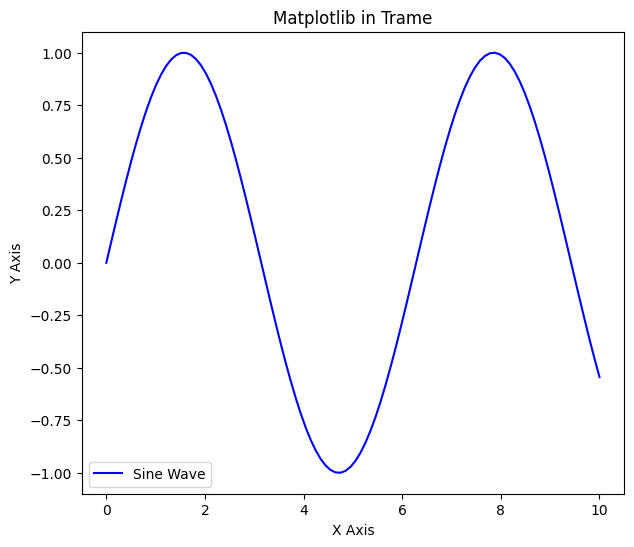

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
x = np.linspace(0, 10, 100)
y = np.sin(x)
# 
ax.plot(x, y, label="Sine Wave", color="blue")
ax.set_title("Matplotlib in Trame")
ax.set_xlabel("X Axis")
ax.set_ylabel("Y Axis")
ax.legend()

In [14]:
class Panel(v3.VCard):
    def __init__(self, title, **kwargs):
        super().__init__(
            variant="outlined",
            classes="h-100",
            **kwargs,
        )

        with self:
            v3.VCardTitle(
                title,
                classes="text-subtitle-1 font-weight-medium",
            )

            v3.VDivider()

            self.content = v3.VCardText(
                classes="pa-2"
            )

class FidesVisClean(TrameApp):
    def __init__(self, server=None):
        super().__init__(server)

        self.reader = ADIOSReader(
            bp_file,
            json_file,
            unstructured_grid,
        )
        
        self.fig = fig
        self.fig_weights = fig
        self.train_losses = []
        self.latent_vectors = []
        self.epochs = []
        self.epoch_count = 0
        self.colors = []
        #self.plot_widget = trame_matplotlib.Figure(figure=self.fig)
        #self.server.state.my_figure_state = 
        #self.plot_widget = self.fig
        #self.top.watch(["mapper_change"], self.render)
        self._build_ui()
        self.selected_field = "Omega"
    
        #self.html_view = trame_vtk.VtkLocalView(renderWindow)
        
    def reset_to_initial_view(self):
        camera = renderer.GetActiveCamera()
        camera_gt = renderer_gt.GetActiveCamera()

        camera.SetPosition(*self.initial_camera["position"])
        camera.SetFocalPoint(*self.initial_camera["focal_point"])
        camera.SetViewUp(*self.initial_camera["view_up"])
        camera.SetViewAngle(self.initial_camera["view_angle"])
        camera.SetClippingRange(*self.initial_camera["clipping_range"])

        camera_gt.SetPosition(*self.initial_camera["position"])
        camera_gt.SetFocalPoint(*self.initial_camera["focal_point"])
        camera_gt.SetViewUp(*self.initial_camera["view_up"])
        camera_gt.SetViewAngle(self.initial_camera["view_angle"])
        camera_gt.SetClippingRange(*self.initial_camera["clipping_range"])

        
        self.html_view.update()
        self.ground_truth_view.update()

        self.html_view.push_camera()
        self.ground_truth_view.push_camera()
        #self.html_view.render()
        #self.ground_truth_view.render()
    
    def reset_view(self):
        self.html_view.reset_camera()
        self.ground_truth_view.reset_camera()

    def next_step(self):

        print("Requesting next ADIOS step...")
        omega, ux, uy, coords = self.reader.read_next_step()
        omega = np.expand_dims(omega, axis=-1)

        vel_mag = np.sqrt(ux ** 2 + uy ** 2)
        vel_mag = np.expand_dims(vel_mag, axis =-1)
        
        features = np.concatenate((coords, omega , vel_mag), axis=-1)
        x_tensor = torch.from_numpy(features).float()

        #print(
        #    f"Loaded step {self.reader.step_number}"
        #)

        #print(shared_grid)
        #point_data = unstructured_grid.GetPointData()
    
        # Tell VTK the data changed
        unstructured_grid.Modified()
        mapper.Modified()

        unstructured_grid_gt.Modified()
        mapper_gt.Modified()

        # First timestep: establish camera
        if self.reader.step_number == 1:
            renderer.ResetCamera()

        # * Call Torch Training
        model_pred, training_loss = self.reader.train_loop(x_tensor, self.reader.step_number)

        # * Update the plot
        pred_grid = gen_tp_from_model(model_pred)
        gt_grid = gen_tp_from_model(features)

        self.epochs.append(self.epoch_count)
        self.train_losses.append(training_loss)

        ## * Plotting Loss
        
        self.fig.clear()

        ax = self.fig.add_subplot(111)
    
        ax.plot(
            self.epochs,
            self.train_losses,
            color = '#7E87F5',
            linewidth=2.5,
            label="Training Loss", 
            zorder = 1
        )

        
        self.colors.append((self.reader.step_number%5) * 10)

            
        ax.scatter(
            self.epochs,
            self.train_losses,
            c = self.colors,
            cmap = "magma",
            label="Training Loss", 
             s=50,
            zorder=2
        )
    
        ax.set_title("Model Loss Progression", fontsize=22)
        ax.set_xlabel("Epoch", fontsize=20)
        ax.tick_params(labelsize=15)
        ax.set_ylabel("Loss (MSE)", fontsize=20)
        #ax.legend()
    
        self.fig.tight_layout()

        # Tell Trame that the figure changed
        self.plot_widget.update(figure=self.fig)
        
        self.epoch_count+=5

        ## [Working] Plotting LCA rep

        self.fig_weights.clear()
        #data = self.reader.model.conv1.weight.detach().numpy()

        #self.html_view.update()
        #self.ground_truth_view.update()
        ## [Working] Plotting model weights example, 

        #self.fig_weights.clear()
        data = self.reader.model.conv1.weight.detach().numpy()

        ax_weight = self.fig_weights.add_subplot(111)

        x_indices = np.repeat(np.arange(data.shape[0]), data.shape[1])
        y_values = data.flatten()
        
        ax_weight.scatter(
            x=x_indices,
            y=y_values,
            c=y_values,
            cmap="berlin",
            s=50
        )
        ax_weight.set_title("Layer 1 Weights", fontsize=22)
        ax_weight.set_xlabel("Param. Number", fontsize=20)
        ax_weight.set_ylabel("Weight Value", fontsize=20)
        ax_weight.tick_params(labelsize=15)
        ax_weight.legend()
        
        self.plot_widget_weights.update(figure=self.fig_weights)

        unstructured_grid.DeepCopy(pred_grid)
        unstructured_grid_gt.DeepCopy(gt_grid)
        
        self.html_view.update()
        self.ground_truth_view.update()

    def _build_ui(self):
        with SinglePageLayout(self.server) as self.ui:
            self.ui.title.set_text("Cylinder2D Autoencoder Training")
            from trame.widgets import matplotlib as trame_matplotlib
            #with self.ui.icon:
            #    vuetify.VIcon("mdi-brain")

            myPurple = "#44355b"
            myBlue = "#31263e"
            myOrange = "#ee5622"

            with self.ui.icon:
                v3.VIcon("mdi-coffee-machine")
            with self.ui.toolbar:
                v3.VIcon("mdi-coffee-machine")
                v3.VBtn(
                    "Reset to Iso. View",
                    click=self.reset_view,
                    style=f"background-color: {myPurple}; color: white;"
                )
                v3.VBtn(
                    "Reset to Init. View",
                    click=self.reset_to_initial_view,
                    style=f"background-color: {myBlue}; color: white;"
                )
                v3.VBtn(
                    "Next Step",
                    click=self.next_step,
                    style=f"background-color: {myOrange}; color: white;"
                )
                v3.VSelect(
                    label="Field",
                    items=["Velocity", "Omega", "Pressure"],
                    v_model=("selected_field",),
                    style="max-width: 120px;",
                )

            #    xaitk_widgets.Toolbar(self.on_add_model)
            
            with self.ui.content:
                # Relative container allows absolute positioning inside it
                with v3.VContainer(fluid=True, classes="pa-0"):
                                    
                    # Top row for graphing
                    # ---------------------------------
                    # Top row
                    # ---------------------------------
                    with v3.VRow(
                        style="min-width: 0;",
                        classes="d-flex flex-shrink-1"
                    ):
                
                        with v3.VCol(cols="12", sm="6"):
                
                            with Panel("Loss Plot Graph"):
                
                                self.plot_widget = trame_matplotlib.Figure(
                                    figure=self.fig,
                                )
                
                        with v3.VCol(cols="12", sm="6"):
                
                            with Panel("Ground Truth"):
                
                                self.ground_truth_view = trame_vtk.VtkLocalView(
                                    renderWindow_gt,
                                    style="width: 100%; height: 500px;"
                                )
                
                                self.ctrl.on_server_ready.add(
                                    self.ground_truth_view.update
                                )
                
                    # ---------------------------------
                    # Bottom row
                    # ---------------------------------
                    with v3.VRow(
                        style="min-width: 0;",
                        classes="d-flex flex-shrink-1"
                    ):
                
                        with v3.VCol(cols="12", sm="6"):
                
                            with Panel("Model Prediction"):
                
                                self.html_view = trame_vtk.VtkLocalView(
                                    renderWindow,
                                    style="width: 100%; height: 500px;"
                                )
                                print("self.html_view.renderWindow")
                                print(self.html_view.renderWindow)
                                camera = renderer.GetActiveCamera()

                                self.initial_camera = {
                                    "position": camera.GetPosition(),
                                    "focal_point": camera.GetFocalPoint(),
                                    "view_up": camera.GetViewUp(),
                                    "view_angle": camera.GetViewAngle(),
                                    "clipping_range": camera.GetClippingRange(),
                                }
                                self.ctrl.on_server_ready.add(
                                    self.html_view.update
                                )
                
                                
                
                        with v3.VCol(cols="12", sm="6"):
                
                            with Panel("Layer 1 Weight Visualization"):
                
                                self.plot_widget_weights = trame_matplotlib.Figure(
                                    figure=self.fig_weights,
                                )
                                            
                
                
                
                


In [15]:
app = FidesVisClean()
await app.display_cell(height="800px")

HTML(value='<iframe id="trame_trame__template_main" src="http://localhost:33051/index.html?ui=main&reconnect=a…

[INFER] 127.0.0.1 [01/Sep/2026:16:53:56 -0400] "GET /index.html?ui=main&reconnect=auto HTTP/1.1" 200 237 "http://localhost:8888/" "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/150.0.0.0 Safari/537.36"
[INFER] 127.0.0.1 [01/Sep/2026:16:53:56 -0400] "GET /assets/index-faLoIDve.css HTTP/1.1" 200 235 "http://localhost:33051/index.html?ui=main&reconnect=auto" "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/150.0.0.0 Safari/537.36"
[INFER] 127.0.0.1 [01/Sep/2026:16:53:56 -0400] "GET /vue.global.js HTTP/1.1" 200 254 "http://localhost:33051/index.html?ui=main&reconnect=auto" "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/150.0.0.0 Safari/537.36"
[INFER] 127.0.0.1 [01/Sep/2026:16:53:56 -0400] "GET /assets/index-DBTNMoYm.js HTTP/1.1" 200 253 "http://localhost:33051/index.html?ui=main&reconnect=auto" "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/150.0.0.0 Safari/537.36"

Requesting next ADIOS step...
ADIOS READ NEXT STEP


/home/local/KHQ/ayman.yousef/Downloads/trame_py3_10/.venv/lib/python3.10/site-packages/torch/nn/modules/loss.py:630: UserWarning: Using a target size (torch.Size([7500, 5])) that is different to the input size (torch.Size([1, 7500, 5])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/tmp/ipykernel_1323855/1773488642.py:186: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_weight.legend()
/home/local/KHQ/ayman.yousef/Downloads/trame_py3_10/.venv/lib/python3.10/site-packages/mpld3/mplexporter/exporter.py:179: UserWarning: Legend element <matplotlib.offsetbox.HPacker object at 0x75fac8646260> not impemented
  warnings.warn("Legend element %s not impemented" % child)
[INFER] client bb884ddc387b4c31acba0bb5c34991ed disconnected
[INFER] No more connect